# Bicep Curl Deep Learning Model Pipeline

## Author: [Sunny Shaban Ali](https://www.github.com/sunnyallana)

## Reference: [NgoQuocBao1010](https://github.com/NgoQuocBao1010/Exercise-Correction/tree/main)


## Installing Dependencies

In [ ]:
!pip install keras-tuner mediapipe

## 7-layer deep-learning model for bicep curl detection

In [ ]:
# Data visualization and processing
import numpy as np
import pandas as pd
import os

# TensorFlow/Keras for deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import keras_tuner as kt

# Train-Test split and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

import pickle
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Important body landmarks for bicep exercise classification
BICEP_LANDMARKS = [
    "NOSE",
    "LEFT_SHOULDER",
    "RIGHT_SHOULDER",
    "RIGHT_ELBOW",
    "LEFT_ELBOW",
    "RIGHT_WRIST",
    "LEFT_WRIST",
    "LEFT_HIP",
    "RIGHT_HIP",
]

# Generate column headers for the dataset
DATASET_COLUMNS = ["label"]  # Classification label column

for landmark in BICEP_LANDMARKS:
    DATASET_COLUMNS += [
        f"{landmark.lower()}_x",
        f"{landmark.lower()}_y",
        f"{landmark.lower()}_z",
        f"{landmark.lower()}_v"
    ]


def create_required_directories():
    """Create necessary directories if they don't exist"""
    required_dirs = ["./model", "./keras_tuner_dir", "./keras_tuner_dir/logs"]
    for directory in required_dirs:
        os.makedirs(directory, exist_ok=True)


def analyze_dataset(dataset_file_path: str):
    """
    Analyze and describe the dataset
    """
    if not os.path.exists(dataset_file_path):
        print(f"Error: Dataset file {dataset_file_path} not found!")
        return None

    dataset = pd.read_csv(dataset_file_path)
    print(f"Dataset columns: {list(dataset.columns.values)}")
    print(f'Dataset shape: {dataset.shape[0]} rows x {dataset.shape[1]} columns\n')
    print(f"Class distribution: \n{dataset['label'].value_counts()}\n")
    print(f"Missing values present: {dataset.isnull().values.any()}\n")

    duplicate_rows = dataset[dataset.duplicated()]
    print(f"Duplicate rows found: {len(duplicate_rows)}")

    return dataset


def clean_duplicate_data(dataset_file_path: str, output_filename: str = "cleaned_train.csv"):
    """
    Remove duplicate rows from dataset and save cleaned version
    """
    if not os.path.exists(dataset_file_path):
        print(f"Error: Dataset file {dataset_file_path} not found!")
        return

    dataset_df = pd.read_csv(dataset_file_path)
    original_size = len(dataset_df)
    dataset_df.drop_duplicates(keep="first", inplace=True)
    cleaned_size = len(dataset_df)

    dataset_df.to_csv(output_filename, sep=',', encoding='utf-8', index=False)
    print(f"Removed {original_size - cleaned_size} duplicate rows")
    print(f"Cleaned dataset saved to {output_filename}")


def round_metric_scores(metric_scores) -> list:
    """Round metric scores to 3 decimal places"""
    return [round(score, 3) for score in metric_scores]


def display_model_architecture(neural_network_model):
    """
    Display the architecture of the neural network model
    """
    print("Neural Network Architecture:")
    print("-" * 40)
    for layer_index, layer in enumerate(neural_network_model.layers):
        layer_units = getattr(layer, 'units', 0)

        if hasattr(layer, "activation"):
            activation_function = layer.activation.__name__ if hasattr(layer.activation, '__name__') else str(layer.activation)
            print(f"Layer {layer_index + 1}: {layer_units} units, activation: {activation_function}")
        else:
            print(f"Layer {layer_index + 1}: {layer_units} units, activation: None")


def get_optimized_model(hyperparameter_tuner):
    """
    Get the best model found by hyperparameter tuning
    """
    best_hyperparameters = hyperparameter_tuner.get_best_hyperparameters(num_trials=1)[0]
    optimized_model = hyperparameter_tuner.hypermodel.build(best_hyperparameters)

    display_model_architecture(optimized_model)

    print("\nOptimal Hyperparameters:")
    print("-" * 30)
    excluded_params = ["tuner", "activation", "layer", "epoch"]
    for param_name, param_value in best_hyperparameters.values.items():
        if not any(excluded_word in param_name for excluded_word in excluded_params):
            print(f"{param_name}: {param_value}")

    return optimized_model


def build_seven_layer_model(hyperparameters):
    """
    Build a 7-layer deep neural network model for bicep exercise classification
    """
    # Clear any existing models to avoid naming conflicts
    tf.keras.backend.clear_session()

    deep_learning_model = Sequential(name="BicepClassifier_7Layer")

    # Input layer
    deep_learning_model.add(Dense(36, input_dim=36, activation="relu"))

    # Hyperparameters for tuning
    optimal_activation = hyperparameters.Choice('activation_function', values=['relu', 'tanh'])
    hidden_layer_1_units = hyperparameters.Int('hidden_layer_1', min_value=32, max_value=512, step=32)
    hidden_layer_2_units = hyperparameters.Int('hidden_layer_2', min_value=32, max_value=512, step=32)
    hidden_layer_3_units = hyperparameters.Int('hidden_layer_3', min_value=32, max_value=512, step=32)
    hidden_layer_4_units = hyperparameters.Int('hidden_layer_4', min_value=32, max_value=512, step=32)
    hidden_layer_5_units = hyperparameters.Int('hidden_layer_5', min_value=32, max_value=512, step=32)
    optimal_learning_rate = hyperparameters.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    # Hidden layers
    deep_learning_model.add(Dense(units=hidden_layer_1_units, activation=optimal_activation))
    deep_learning_model.add(Dense(units=hidden_layer_2_units, activation=optimal_activation))
    deep_learning_model.add(Dense(units=hidden_layer_3_units, activation=optimal_activation))
    deep_learning_model.add(Dense(units=hidden_layer_4_units, activation=optimal_activation))
    deep_learning_model.add(Dense(units=hidden_layer_5_units, activation=optimal_activation))

    # Output layer (binary classification: Correct vs Low bicep curl)
    deep_learning_model.add(Dense(2, activation="softmax"))

    # Compile the model
    deep_learning_model.compile(
        optimizer=Adam(learning_rate=optimal_learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return deep_learning_model


def evaluate_model_performance(trained_model, test_features, test_labels_categorical, test_labels_original):
    """
    Evaluate model performance and return metrics
    """
    # Make predictions
    prediction_probabilities = trained_model.predict(test_features, verbose=0)
    predicted_classes = np.argmax(prediction_probabilities, axis=1)
    actual_classes = np.argmax(test_labels_categorical, axis=1)

    # Calculate metrics
    confusion_matrix_result = confusion_matrix(actual_classes, predicted_classes, labels=[0, 1])
    precision_scores, recall_scores, f1_scores, _ = precision_recall_fscore_support(
        actual_classes, predicted_classes, labels=[0, 1], average=None
    )

    return {
        'confusion_matrix': confusion_matrix_result,
        'precision': round_metric_scores(precision_scores),
        'recall': round_metric_scores(recall_scores),
        'f1_score': round_metric_scores(f1_scores)
    }


def main():
    """
    Main training pipeline for bicep exercise classification
    """
    print("=== Bicep Exercise Classification Training ===\n")

    # Create necessary directories
    create_required_directories()

    # Load and analyze training dataset
    print("Loading and analyzing training dataset...")
    training_dataset = analyze_dataset("./train.csv")

    if training_dataset is None:
        print("Cannot proceed without training data. Please ensure train.csv exists.")
        return

    # Encode labels: 'C' (Correct) = 0, 'L' (Low) = 1
    print("Encoding class labels...")
    training_dataset.loc[training_dataset["label"] == "C", "label"] = 0
    training_dataset.loc[training_dataset["label"] == "L", "label"] = 1

    # Handle feature scaling
    scaler_file_path = "./model/input_scaler.pkl"
    if os.path.exists(scaler_file_path):
        with open(scaler_file_path, "rb") as scaler_file:
            feature_scaler = pickle.load(scaler_file)
        print("Loaded existing feature scaler")
    else:
        print("Creating new StandardScaler for feature normalization...")
        feature_scaler = StandardScaler()
        training_features_raw = training_dataset.drop("label", axis=1)
        feature_scaler.fit(training_features_raw)
        with open(scaler_file_path, "wb") as scaler_file:
            pickle.dump(feature_scaler, scaler_file)
        print("Created and saved new feature scaler")

    # Prepare features and labels
    training_features_raw = training_dataset.drop("label", axis=1)
    training_features_scaled = pd.DataFrame(feature_scaler.transform(training_features_raw))
    training_labels = training_dataset["label"]

    # Convert labels to categorical (one-hot encoding)
    training_labels_categorical = to_categorical(training_labels, num_classes=2)

    # Split data for training and validation
    train_features, validation_features, train_labels, validation_labels = train_test_split(
        training_features_scaled.values, training_labels_categorical,
        test_size=0.2, random_state=1234, stratify=training_labels
    )

    print(f"Training set shape: {train_features.shape}")
    print(f"Validation set shape: {validation_features.shape}")

    # Setup training callbacks
    early_stopping_callback = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    tensorboard_callback = TensorBoard(
        log_dir="./keras_tuner_dir/logs",
        histogram_freq=1
    )

    # Clear any existing tuner directories to avoid conflicts
    tuner_dir = 'keras_tuner_dir'
    if os.path.exists(tuner_dir):
        import shutil
        shutil.rmtree(tuner_dir)

    # Hyperparameter tuning
    print("\nStarting hyperparameter optimization...")
    hyperparameter_tuner = kt.Hyperband(
        build_seven_layer_model,
        objective='val_accuracy',
        max_epochs=15,
        directory='keras_tuner_dir',
        project_name='bicep_classification_tuning',
        overwrite=True  # This ensures fresh start
    )

    hyperparameter_tuner.search(
        train_features, train_labels,
        validation_data=(validation_features, validation_labels),
        epochs=15,
        callbacks=[early_stopping_callback],
        verbose=1
    )

    # Get the best model
    print("\nRetrieving optimized model...")
    optimized_bicep_classifier = get_optimized_model(hyperparameter_tuner)

    # Train the final model
    print("\nTraining the final optimized model...")
    training_history = optimized_bicep_classifier.fit(
        train_features, train_labels,
        epochs=100,
        batch_size=16,
        validation_data=(validation_features, validation_labels),
        callbacks=[early_stopping_callback, tensorboard_callback],
        verbose=1
    )

    # Evaluate on validation set
    print("\n" + "="*60)
    print("VALIDATION SET EVALUATION")
    print("="*60)

    validation_metrics = evaluate_model_performance(
        optimized_bicep_classifier,
        validation_features,
        validation_labels,
        np.argmax(validation_labels, axis=1)
    )

    print(f"Precision scores: {validation_metrics['precision']}")
    print(f"Recall scores: {validation_metrics['recall']}")
    print(f"F1 scores: {validation_metrics['f1_score']}")
    print(f"Confusion Matrix:\n{validation_metrics['confusion_matrix']}")

    # Test set evaluation (if available)
    if os.path.exists("./test.csv"):
        print("\n" + "="*60)
        print("TEST SET EVALUATION")
        print("="*60)

        test_dataset = analyze_dataset("./test.csv")

        if test_dataset is not None:
            # Encode test labels
            test_dataset.loc[test_dataset["label"] == "C", "label"] = 0
            test_dataset.loc[test_dataset["label"] == "L", "label"] = 1

            # Prepare test features
            test_features_raw = test_dataset.drop("label", axis=1)
            test_features_scaled = pd.DataFrame(feature_scaler.transform(test_features_raw))
            test_labels = test_dataset["label"]
            test_labels_categorical = to_categorical(test_labels, num_classes=2)

            # Evaluate on test set
            test_metrics = evaluate_model_performance(
                optimized_bicep_classifier,
                test_features_scaled.values,
                test_labels_categorical,
                test_labels.values
            )

            print(f"Test Precision scores: {test_metrics['precision']}")
            print(f"Test Recall scores: {test_metrics['recall']}")
            print(f"Test F1 scores: {test_metrics['f1_score']}")
            print(f"Test Confusion Matrix:\n{test_metrics['confusion_matrix']}")

    # Save the trained model
    print("\nSaving the trained model...")
    model_save_path = "./model/bicep_classifier_7layer.pkl"
    with open(model_save_path, "wb") as model_file:
        pickle.dump(optimized_bicep_classifier, model_file)

    print(f"Model saved successfully to {model_save_path}")
    print("\n=== Training Pipeline Completed Successfully! ===")


if __name__ == "__main__":
    main()

Trial 30 Complete [00h 00m 32s]
val_accuracy: 0.9977235794067383

Best val_accuracy So Far: 0.9983739852905273
Total elapsed time: 00h 07m 50s

Retrieving optimized model...
Neural Network Architecture:
----------------------------------------
Layer 1: 36 units, activation: relu
Layer 2: 96 units, activation: relu
Layer 3: 384 units, activation: relu
Layer 4: 416 units, activation: relu
Layer 5: 96 units, activation: relu
Layer 6: 224 units, activation: relu
Layer 7: 2 units, activation: softmax

Optimal Hyperparameters:
------------------------------
learning_rate: 0.001

Training the final optimized model...
Epoch 1/100
769/769 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9585 - loss: 0.1161 - val_accuracy: 0.9961 - val_loss: 0.0240
Epoch 2/100
769/769 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9932 - loss: 0.0227 - val_accuracy: 0.9967 - val_loss: 0.0181
Epoch 3/100
769/769 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9949 - loss: 0.0168 - val_accuracy: 0.9974 - val_loss: 0.

## Local Testing

In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import datetime
import pickle
import warnings
warnings.filterwarnings('ignore')

# Drawing helpers
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Determine important landmarks for plank
IMPORTANT_LMS = [
    "NOSE", "LEFT_SHOULDER", "RIGHT_SHOULDER", "RIGHT_ELBOW", "LEFT_ELBOW",
    "RIGHT_WRIST", "LEFT_WRIST", "LEFT_HIP", "RIGHT_HIP",
]

# Generate all columns of the data frame
HEADERS = ["label"]  # Label column
for lm in IMPORTANT_LMS:
    HEADERS += [f"{lm.lower()}_x", f"{lm.lower()}_y", f"{lm.lower()}_z", f"{lm.lower()}_v"]

def rescale_frame(frame, percent=50):
    '''
    Rescale a frame from OpenCV to a certain percentage compare to its original frame
    '''
    width = int(frame.shape[1] * percent / 100)
    height = int(frame.shape[0] * percent / 100)
    dim = (width, height)
    return cv2.resize(frame, dim, interpolation=cv2.INTER_AREA)

def save_frame_as_image(frame, message: str = None):
    '''
    Save a frame as image to display the error
    '''
    now = datetime.datetime.now()
    if message:
        cv2.putText(frame, message, (50, 150), cv2.FONT_HERSHEY_COMPLEX, 0.4, (0, 0, 0), 1, cv2.LINE_AA)
    print("Saving ...")
    cv2.imwrite(f"../data/logs/bicep_{now}.jpg", frame)

def calculate_angle(point1: list, point2: list, point3: list) -> float:
    '''
    Calculate the angle between 3 points
    Unit of the angle will be in Degree
    '''
    point1 = np.array(point1)
    point2 = np.array(point2)
    point3 = np.array(point3)

    # Calculate algo
    angleInRad = np.arctan2(point3[1] - point2[1], point3[0] - point2[0]) - np.arctan2(point1[1] - point2[1], point1[0] - point2[0])
    angleInDeg = np.abs(angleInRad * 180.0 / np.pi)
    angleInDeg = angleInDeg if angleInDeg <= 180 else 360 - angleInDeg
    return angleInDeg

def extract_important_keypoints(results, important_landmarks: list) -> list:
    '''
    Extract important keypoints from mediapipe pose detection
    '''
    landmarks = results.pose_landmarks.landmark
    data = []
    for lm in important_landmarks:
        keypoint = landmarks[mp_pose.PoseLandmark[lm].value]
        data.append([keypoint.x, keypoint.y, keypoint.z, keypoint.visibility])
    return np.array(data).flatten().tolist()

class BicepPoseAnalysis:
    def __init__(self, side: str, stage_down_threshold: float, stage_up_threshold: float, peak_contraction_threshold: float, loose_upper_arm_angle_threshold: float, visibility_threshold: float):
        # Initialize thresholds
        self.stage_down_threshold = stage_down_threshold
        self.stage_up_threshold = stage_up_threshold
        self.peak_contraction_threshold = peak_contraction_threshold
        self.loose_upper_arm_angle_threshold = loose_upper_arm_angle_threshold
        self.visibility_threshold = visibility_threshold

        self.side = side
        self.counter = 0
        self.stage = "down"
        self.is_visible = True
        self.detected_errors = {
            "LOOSE_UPPER_ARM": 0,
            "PEAK_CONTRACTION": 0,
        }

        # Params for loose upper arm error detection
        self.loose_upper_arm = False

        # Params for peak contraction error detection
        self.peak_contraction_angle = 1000
        self.peak_contraction_frame = None

    def get_joints(self, landmarks) -> bool:
        '''
        Check for joints' visibility then get joints coordinate
        '''
        side = self.side.upper()

        # Check visibility
        joints_visibility = [
            landmarks[mp_pose.PoseLandmark[f"{side}_SHOULDER"].value].visibility,
            landmarks[mp_pose.PoseLandmark[f"{side}_ELBOW"].value].visibility,
            landmarks[mp_pose.PoseLandmark[f"{side}_WRIST"].value].visibility
        ]

        is_visible = all([vis > self.visibility_threshold for vis in joints_visibility])
        self.is_visible = is_visible

        if not is_visible:
            return self.is_visible

        # Get joints' coordinates
        self.shoulder = [
            landmarks[mp_pose.PoseLandmark[f"{side}_SHOULDER"].value].x,
            landmarks[mp_pose.PoseLandmark[f"{side}_SHOULDER"].value].y
        ]
        self.elbow = [
            landmarks[mp_pose.PoseLandmark[f"{side}_ELBOW"].value].x,
            landmarks[mp_pose.PoseLandmark[f"{side}_ELBOW"].value].y
        ]
        self.wrist = [
            landmarks[mp_pose.PoseLandmark[f"{side}_WRIST"].value].x,
            landmarks[mp_pose.PoseLandmark[f"{side}_WRIST"].value].y
        ]

        return self.is_visible

    def analyze_pose(self, landmarks, frame):
        '''
        - Bicep Counter
        - Errors Detection
        '''
        self.get_joints(landmarks)

        # Cancel calculation if visibility is poor
        if not self.is_visible:
            return (None, None)

        # * Calculate curl angle for counter
        bicep_curl_angle = int(calculate_angle(self.shoulder, self.elbow, self.wrist))
        if bicep_curl_angle > self.stage_down_threshold:
            self.stage = "down"
        elif bicep_curl_angle < self.stage_up_threshold and self.stage == "down":
            self.stage = "up"
            self.counter += 1

        # * Calculate the angle between the upper arm (shoulder & joint) and the Y axis
        shoulder_projection = [self.shoulder[0], 1]  # Represent the projection of the shoulder to the X axis
        ground_upper_arm_angle = int(calculate_angle(self.elbow, self.shoulder, shoulder_projection))

        # * Evaluation for LOOSE UPPER ARM error
        if ground_upper_arm_angle > self.loose_upper_arm_angle_threshold:
            # Limit the saved frame
            if not self.loose_upper_arm:
                self.loose_upper_arm = True
                # save_frame_as_image(frame, f"Loose upper arm: {ground_upper_arm_angle}")
                self.detected_errors["LOOSE_UPPER_ARM"] += 1
        else:
            self.loose_upper_arm = False

        # * Evaluate PEAK CONTRACTION error
        if self.stage == "up" and bicep_curl_angle < self.peak_contraction_angle:
            # Save peaked contraction every rep
            self.peak_contraction_angle = bicep_curl_angle
            self.peak_contraction_frame = frame

        elif self.stage == "down":
            # * Evaluate if the peak is higher than the threshold if True, marked as an error then saved that frame
            if self.peak_contraction_angle != 1000 and self.peak_contraction_angle >= self.peak_contraction_threshold:
                # save_frame_as_image(self.peak_contraction_frame, f"{self.side} - Peak Contraction: {self.peak_contraction_angle}")
                self.detected_errors["PEAK_CONTRACTION"] += 1

            # Reset params
            self.peak_contraction_angle = 1000
            self.peak_contraction_frame = None

        return (bicep_curl_angle, ground_upper_arm_angle)

# Use camera instead of video file (0 is default camera, 1 for external camera)

cap = cv2.VideoCapture(0)

# Set camera resolution (optional)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

VISIBILITY_THRESHOLD = 0.65

# Params for counter
STAGE_UP_THRESHOLD = 90
STAGE_DOWN_THRESHOLD = 120

# Params to catch FULL RANGE OF MOTION error
PEAK_CONTRACTION_THRESHOLD = 60

# LOOSE UPPER ARM error detection
LOOSE_UPPER_ARM = False
LOOSE_UPPER_ARM_ANGLE_THRESHOLD = 40

# STANDING POSTURE error detection
POSTURE_ERROR_THRESHOLD = 0.95
posture = 0

# Init analysis class
left_arm_analysis = BicepPoseAnalysis(
    side="left",
    stage_down_threshold=STAGE_DOWN_THRESHOLD,
    stage_up_threshold=STAGE_UP_THRESHOLD,
    peak_contraction_threshold=PEAK_CONTRACTION_THRESHOLD,
    loose_upper_arm_angle_threshold=LOOSE_UPPER_ARM_ANGLE_THRESHOLD,
    visibility_threshold=VISIBILITY_THRESHOLD
)

right_arm_analysis = BicepPoseAnalysis(
    side="right",
    stage_down_threshold=STAGE_DOWN_THRESHOLD,
    stage_up_threshold=STAGE_UP_THRESHOLD,
    peak_contraction_threshold=PEAK_CONTRACTION_THRESHOLD,
    loose_upper_arm_angle_threshold=LOOSE_UPPER_ARM_ANGLE_THRESHOLD,
    visibility_threshold=VISIBILITY_THRESHOLD
)

# Load input scaler
try:
    with open("./model/input_scaler.pkl", "rb") as f:
        input_scaler = pickle.load(f)
except FileNotFoundError:
    print("Warning: input_scaler.pkl not found. Skipping posture analysis.")
    input_scaler = None

# Load model
try:
    with open("./model/bicep_classifier_7layer.pkl", "rb") as f:
        DL_model = pickle.load(f)
except FileNotFoundError:
    print("Warning: bicep_dp.pkl not found. Skipping posture analysis.")
    DL_model = None

print("Starting camera capture... Press 'q' to quit")

with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    while cap.isOpened():
        ret, image = cap.read()

        if not ret:
            print("Failed to capture image from camera")
            break

        # Flip image horizontally for mirror effect (optional)
        image = cv2.flip(image, 1)

        # Reduce size of a frame (optional, comment out if you want full resolution)
        # image = rescale_frame(image, 40)

        video_dimensions = [image.shape[1], image.shape[0]]

        # Recolor image from BGR to RGB for mediapipe
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image.flags.writeable = False

        results = pose.process(image)

        if not results.pose_landmarks:
            # Recolor back to BGR for display
            image.flags.writeable = True
            image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
            cv2.putText(image, "No human detected", (50, 50), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
            cv2.imshow("Bicep Curl Analysis", image)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
            continue

        # Recolor image from RGB to BGR for OpenCV
        image.flags.writeable = True
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

        # Draw landmarks and connections
        mp_drawing.draw_landmarks(
            image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(244, 117, 66), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=1)
        )

        # Make detection
        try:
            landmarks = results.pose_landmarks.landmark

            (left_bicep_curl_angle, left_ground_upper_arm_angle) = left_arm_analysis.analyze_pose(landmarks=landmarks, frame=image)
            (right_bicep_curl_angle, right_ground_upper_arm_angle) = right_arm_analysis.analyze_pose(landmarks=landmarks, frame=image)

            # Posture analysis (only if models are loaded)
            if input_scaler is not None and DL_model is not None:
                # Extract keypoints from frame for the input
                row = extract_important_keypoints(results, IMPORTANT_LMS)
                X = pd.DataFrame([row, ], columns=HEADERS[1:])
                X = pd.DataFrame(input_scaler.transform(X))

                # Make prediction and its probability
                prediction = DL_model.predict(X)
                predicted_class = np.argmax(prediction, axis=1)[0]
                prediction_probability = round(max(prediction.tolist()[0]), 2)

                if prediction_probability >= POSTURE_ERROR_THRESHOLD:
                    posture = predicted_class
            else:
                predicted_class = 0
                prediction_probability = 0.0

            # Visualization - Centered metrics panel
            frame_width = image.shape[1]

            # Create centered black background for metrics
            panel_width = 700
            panel_height = 70
            panel_x = (frame_width - panel_width) // 2
            panel_y = 10

            # Draw black background rectangle
            cv2.rectangle(image, (panel_x, panel_y), (panel_x + panel_width, panel_y + panel_height), (0, 0, 0), -1)

            # Draw border
            cv2.rectangle(image, (panel_x, panel_y), (panel_x + panel_width, panel_y + panel_height), (255, 255, 255), 2)

            # Text settings
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.6
            text_color = (255, 255, 255)  # White text
            thickness = 2

            # Row 1 - Labels
            y_offset = panel_y + 20
            cv2.putText(image, "RIGHT", (panel_x + 20, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, "LEFT", (panel_x + 120, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, "R_PC", (panel_x + 220, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, "R_LUA", (panel_x + 300, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, "L_PC", (panel_x + 400, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, "L_LUA", (panel_x + 480, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, "POSTURE", (panel_x + 580, y_offset), font, font_scale, text_color, thickness)

            # Row 2 - Values
            y_offset = panel_y + 50
            cv2.putText(image, str(right_arm_analysis.counter) if right_arm_analysis.is_visible else "UNK",
                       (panel_x + 35, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, str(left_arm_analysis.counter) if left_arm_analysis.is_visible else "UNK",
                       (panel_x + 125, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, str(right_arm_analysis.detected_errors["PEAK_CONTRACTION"]),
                       (panel_x + 245, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, str(right_arm_analysis.detected_errors["LOOSE_UPPER_ARM"]),
                       (panel_x + 335, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, str(left_arm_analysis.detected_errors["PEAK_CONTRACTION"]),
                       (panel_x + 425, y_offset), font, font_scale, text_color, thickness)
            cv2.putText(image, str(left_arm_analysis.detected_errors["LOOSE_UPPER_ARM"]),
                       (panel_x + 510, y_offset), font, font_scale, text_color, thickness)

            posture_text = f"{'C' if posture == 0 else 'L'} {prediction_probability:.2f}"
            cv2.putText(image, posture_text, (panel_x + 590, y_offset), font, 0.5, text_color, thickness)

            # * Visualize angles
            # Visualize LEFT arm calculated angles
            if left_arm_analysis.is_visible:
                cv2.putText(image, str(left_bicep_curl_angle), tuple(np.multiply(left_arm_analysis.elbow, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
                cv2.putText(image, str(left_ground_upper_arm_angle), tuple(np.multiply(left_arm_analysis.shoulder, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

            # Visualize RIGHT arm calculated angles
            if right_arm_analysis.is_visible:
                cv2.putText(image, str(right_bicep_curl_angle), tuple(np.multiply(right_arm_analysis.elbow, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(right_ground_upper_arm_angle), tuple(np.multiply(right_arm_analysis.shoulder, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)

        except Exception as e:
            print(f"Error: {e}")

        cv2.imshow("Bicep Curl Analysis", image)

        # Press Q to close cv2 window
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    # Fix bugs cannot close windows in MacOS
    for i in range(1, 5):
        cv2.waitKey(1)

print("Camera capture ended.")

## Google Colab Testing

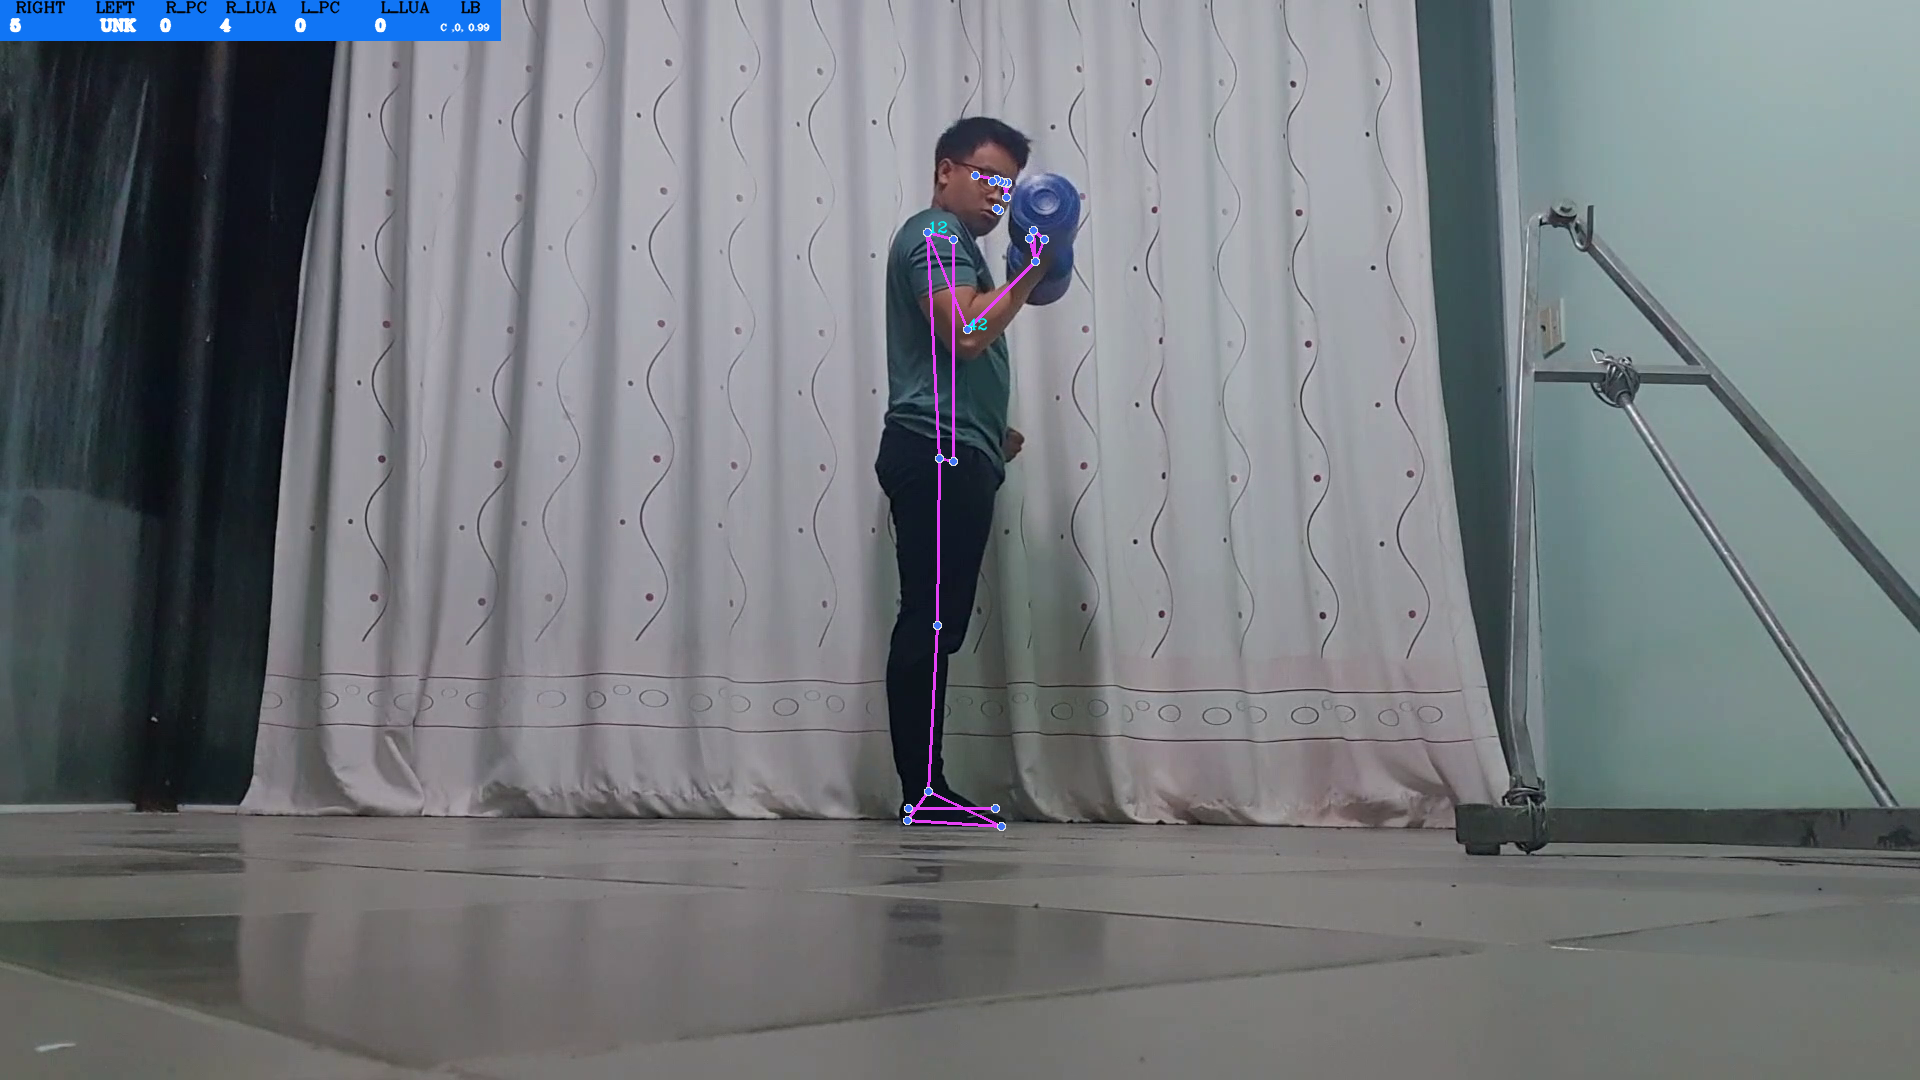

Frame 660/678
Left arm reps: 0, Right arm reps: 5
Left errors - PC: 0, LUA: 0
Right errors - PC: 0, LUA: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

FINAL RESULTS
Total frames processed: 678
Left arm repetitions: 0
Right arm repetitions: 5
Left arm errors:
  - Peak Contraction: 0
  - Loose Upper Arm: 0
Right arm errors:
  - Peak Contraction: 0
  - Loose U

In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import datetime
import pickle
import warnings
from google.colab.patches import cv2_imshow
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
warnings.filterwarnings('ignore')

# Drawing helpers
mp_drawing = mp.solutions.drawing_utils
mp_pose = mp.solutions.pose

# Determine important landmarks for plank
IMPORTANT_LMS = [
    "NOSE", "LEFT_SHOULDER", "RIGHT_SHOULDER", "RIGHT_ELBOW", "LEFT_ELBOW",
    "RIGHT_WRIST", "LEFT_WRIST", "LEFT_HIP", "RIGHT_HIP",
]

# Generate all columns of the data frame
HEADERS = ["label"]  # Label column
for lm in IMPORTANT_LMS:
    HEADERS += [f"{lm.lower()}_x", f"{lm.lower()}_y", f"{lm.lower()}_z", f"{lm.lower()}_v"]

def rescale_frame(frame, percent=50):
    '''
    Rescale a frame from OpenCV to a certain percentage compare to its original frame
    '''
    width = int(frame.shape[1] * percent / 100)
    height = int(frame.shape[0] * percent / 100)
    dim = (width, height)
    return cv2.resize(frame, dim, interpolation=cv2.INTER_AREA)

def save_frame_as_image(frame, message: str = None):
    '''
    Save a frame as image to display the error
    '''
    now = datetime.datetime.now()
    if message:
        cv2.putText(frame, message, (50, 150), cv2.FONT_HERSHEY_COMPLEX, 0.4, (0, 0, 0), 1, cv2.LINE_AA)
    print("Saving ...")
    cv2.imwrite(f"bicep_{now.strftime('%Y%m%d_%H%M%S')}.jpg", frame)

def calculate_angle(point1: list, point2: list, point3: list) -> float:
    '''
    Calculate the angle between 3 points
    Unit of the angle will be in Degree
    '''
    point1 = np.array(point1)
    point2 = np.array(point2)
    point3 = np.array(point3)

    # Calculate algo
    angleInRad = np.arctan2(point3[1] - point2[1], point3[0] - point2[0]) - np.arctan2(point1[1] - point2[1], point1[0] - point2[0])
    angleInDeg = np.abs(angleInRad * 180.0 / np.pi)
    angleInDeg = angleInDeg if angleInDeg <= 180 else 360 - angleInDeg
    return angleInDeg

def extract_important_keypoints(results, important_landmarks: list) -> list:
    '''
    Extract important keypoints from mediapipe pose detection
    '''
    landmarks = results.pose_landmarks.landmark
    data = []
    for lm in important_landmarks:
        keypoint = landmarks[mp_pose.PoseLandmark[lm].value]
        data.append([keypoint.x, keypoint.y, keypoint.z, keypoint.visibility])
    return np.array(data).flatten().tolist()

class BicepPoseAnalysis:
    def __init__(self, side: str, stage_down_threshold: float, stage_up_threshold: float, peak_contraction_threshold: float, loose_upper_arm_angle_threshold: float, visibility_threshold: float):
        # Initialize thresholds
        self.stage_down_threshold = stage_down_threshold
        self.stage_up_threshold = stage_up_threshold
        self.peak_contraction_threshold = peak_contraction_threshold
        self.loose_upper_arm_angle_threshold = loose_upper_arm_angle_threshold
        self.visibility_threshold = visibility_threshold

        self.side = side
        self.counter = 0
        self.stage = "down"
        self.is_visible = True
        self.detected_errors = {
            "LOOSE_UPPER_ARM": 0,
            "PEAK_CONTRACTION": 0,
        }

        # Params for loose upper arm error detection
        self.loose_upper_arm = False

        # Params for peak contraction error detection
        self.peak_contraction_angle = 1000
        self.peak_contraction_frame = None

    def get_joints(self, landmarks) -> bool:
        '''
        Check for joints' visibility then get joints coordinate
        '''
        side = self.side.upper()

        # Check visibility
        joints_visibility = [
            landmarks[mp_pose.PoseLandmark[f"{side}_SHOULDER"].value].visibility,
            landmarks[mp_pose.PoseLandmark[f"{side}_ELBOW"].value].visibility,
            landmarks[mp_pose.PoseLandmark[f"{side}_WRIST"].value].visibility
        ]

        is_visible = all([vis > self.visibility_threshold for vis in joints_visibility])
        self.is_visible = is_visible

        if not is_visible:
            return self.is_visible

        # Get joints' coordinates
        self.shoulder = [
            landmarks[mp_pose.PoseLandmark[f"{side}_SHOULDER"].value].x,
            landmarks[mp_pose.PoseLandmark[f"{side}_SHOULDER"].value].y
        ]
        self.elbow = [
            landmarks[mp_pose.PoseLandmark[f"{side}_ELBOW"].value].x,
            landmarks[mp_pose.PoseLandmark[f"{side}_ELBOW"].value].y
        ]
        self.wrist = [
            landmarks[mp_pose.PoseLandmark[f"{side}_WRIST"].value].x,
            landmarks[mp_pose.PoseLandmark[f"{side}_WRIST"].value].y
        ]

        return self.is_visible

    def analyze_pose(self, landmarks, frame):
        '''
        - Bicep Counter
        - Errors Detection
        '''
        self.get_joints(landmarks)

        # Cancel calculation if visibility is poor
        if not self.is_visible:
            return (None, None)

        # * Calculate curl angle for counter
        bicep_curl_angle = int(calculate_angle(self.shoulder, self.elbow, self.wrist))
        if bicep_curl_angle > self.stage_down_threshold:
            self.stage = "down"
        elif bicep_curl_angle < self.stage_up_threshold and self.stage == "down":
            self.stage = "up"
            self.counter += 1

        # * Calculate the angle between the upper arm (shoulder & joint) and the Y axis
        shoulder_projection = [self.shoulder[0], 1]  # Represent the projection of the shoulder to the X axis
        ground_upper_arm_angle = int(calculate_angle(self.elbow, self.shoulder, shoulder_projection))

        # * Evaluation for LOOSE UPPER ARM error
        if ground_upper_arm_angle > self.loose_upper_arm_angle_threshold:
            # Limit the saved frame
            if not self.loose_upper_arm:
                self.loose_upper_arm = True
                self.detected_errors["LOOSE_UPPER_ARM"] += 1
        else:
            self.loose_upper_arm = False

        # * Evaluate PEAK CONTRACTION error
        if self.stage == "up" and bicep_curl_angle < self.peak_contraction_angle:
            # Save peaked contraction every rep
            self.peak_contraction_angle = bicep_curl_angle
            self.peak_contraction_frame = frame

        elif self.stage == "down":
            # * Evaluate if the peak is higher than the threshold if True, marked as an error then saved that frame
            if self.peak_contraction_angle != 1000 and self.peak_contraction_angle >= self.peak_contraction_threshold:
                self.detected_errors["PEAK_CONTRACTION"] += 1

            # Reset params
            self.peak_contraction_angle = 1000
            self.peak_contraction_frame = None

        return (bicep_curl_angle, ground_upper_arm_angle)

# Function to process video and display results
def process_bicep_curl_video(video_path, display_frames=True, frame_interval=10):
    """
    Process bicep curl video with pose analysis

    Args:
        video_path: Path to the video file
        display_frames: Whether to display frames during processing
        frame_interval: Display every nth frame to avoid overwhelming output
    """

    cap = cv2.VideoCapture(video_path)

    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps

    print(f"Video Info:")
    print(f"- FPS: {fps}")
    print(f"- Total Frames: {total_frames}")
    print(f"- Duration: {duration:.2f} seconds")
    print(f"- Resolution: {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
    print()

    VISIBILITY_THRESHOLD = 0.65

    # Params for counter
    STAGE_UP_THRESHOLD = 90
    STAGE_DOWN_THRESHOLD = 120

    # Params to catch FULL RANGE OF MOTION error
    PEAK_CONTRACTION_THRESHOLD = 60

    # LOOSE UPPER ARM error detection
    LOOSE_UPPER_ARM_ANGLE_THRESHOLD = 40

    # STANDING POSTURE error detection
    POSTURE_ERROR_THRESHOLD = 0.95
    posture = 0

    # Init analysis class
    left_arm_analysis = BicepPoseAnalysis(
        side="left",
        stage_down_threshold=STAGE_DOWN_THRESHOLD,
        stage_up_threshold=STAGE_UP_THRESHOLD,
        peak_contraction_threshold=PEAK_CONTRACTION_THRESHOLD,
        loose_upper_arm_angle_threshold=LOOSE_UPPER_ARM_ANGLE_THRESHOLD,
        visibility_threshold=VISIBILITY_THRESHOLD
    )

    right_arm_analysis = BicepPoseAnalysis(
        side="right",
        stage_down_threshold=STAGE_DOWN_THRESHOLD,
        stage_up_threshold=STAGE_UP_THRESHOLD,
        peak_contraction_threshold=PEAK_CONTRACTION_THRESHOLD,
        loose_upper_arm_angle_threshold=LOOSE_UPPER_ARM_ANGLE_THRESHOLD,
        visibility_threshold=VISIBILITY_THRESHOLD
    )

    # Load input scaler (optional)
    try:
        with open("./model/input_scaler.pkl", "rb") as f:
            input_scaler = pickle.load(f)
        print("✓ Input scaler loaded successfully")
    except FileNotFoundError:
        print("⚠ Warning: input_scaler.pkl not found. Skipping posture analysis.")
        input_scaler = None

    # Load model (optional)
    try:
        with open("./model/bicep_classifier_7layer.pkl", "rb") as f:
            DL_model = pickle.load(f)
        print("✓ DL model loaded successfully")
    except FileNotFoundError:
        print("⚠ Warning: bicep_classifier_7layer.pkl not found. Skipping posture analysis.")
        DL_model = None

    print("\nProcessing video...")

    frame_count = 0
    processed_frames = 0

    with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        while cap.isOpened():
            ret, image = cap.read()

            if not ret:
                break

            frame_count += 1

            # Process every frame but only display some
            video_dimensions = [image.shape[1], image.shape[0]]

            # Recolor image from BGR to RGB for mediapipe
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_rgb.flags.writeable = False

            results = pose.process(image_rgb)

            # Recolor back to BGR for processing
            image_rgb.flags.writeable = True
            image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

            if not results.pose_landmarks:
                cv2.putText(image, "No human detected", (50, 50), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
                if display_frames and frame_count % frame_interval == 0:
                    clear_output(wait=True)
                    cv2_imshow(image)
                    print(f"Frame {frame_count}/{total_frames} - No pose detected")
                continue

            # Draw landmarks and connections
            mp_drawing.draw_landmarks(
                image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(244, 117, 66), thickness=2, circle_radius=2),
                mp_drawing.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=1)
            )

            # Make detection
            try:
                landmarks = results.pose_landmarks.landmark

                (left_bicep_curl_angle, left_ground_upper_arm_angle) = left_arm_analysis.analyze_pose(landmarks=landmarks, frame=image)
                (right_bicep_curl_angle, right_ground_upper_arm_angle) = right_arm_analysis.analyze_pose(landmarks=landmarks, frame=image)

                # Posture analysis (only if models are loaded)
                predicted_class = 0
                prediction_probability = 0.0

                if input_scaler is not None and DL_model is not None:
                    # Extract keypoints from frame for the input
                    row = extract_important_keypoints(results, IMPORTANT_LMS)
                    X = pd.DataFrame([row, ], columns=HEADERS[1:])
                    X = pd.DataFrame(input_scaler.transform(X))

                    # Make prediction and its probability
                    prediction = DL_model.predict(X)
                    predicted_class = np.argmax(prediction, axis=1)[0]
                    prediction_probability = round(max(prediction.tolist()[0]), 2)

                    if prediction_probability >= POSTURE_ERROR_THRESHOLD:
                        posture = predicted_class

                # Add visualization elements
                # Status box
                cv2.rectangle(image, (0, 0), (500, 40), (245, 117, 16), -1)

                # Display Right Counter
                cv2.putText(image, "RIGHT", (15, 12), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(right_arm_analysis.counter) if right_arm_analysis.is_visible else "UNK", (10, 30), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)

                # Display Left Counter
                cv2.putText(image, "LEFT", (95, 12), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(left_arm_analysis.counter) if left_arm_analysis.is_visible else "UNK", (100, 30), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)

                # Display errors
                # Right arm error
                cv2.putText(image, "R_PC", (165, 12), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(right_arm_analysis.detected_errors["PEAK_CONTRACTION"]), (160, 30), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)
                cv2.putText(image, "R_LUA", (225, 12), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(right_arm_analysis.detected_errors["LOOSE_UPPER_ARM"]), (220, 30), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)

                # Left arm error
                cv2.putText(image, "L_PC", (300, 12), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(left_arm_analysis.detected_errors["PEAK_CONTRACTION"]), (295, 30), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)
                cv2.putText(image, "L_LUA", (380, 12), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str(left_arm_analysis.detected_errors["LOOSE_UPPER_ARM"]), (375, 30), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 2, cv2.LINE_AA)

                # Lean back error
                cv2.putText(image, "LB", (460, 12), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
                cv2.putText(image, str("C" if posture == 0 else "L") + f" ,{predicted_class}, {prediction_probability}", (440, 30), cv2.FONT_HERSHEY_COMPLEX, 0.3, (255, 255, 255), 1, cv2.LINE_AA)

                # Visualize angles
                # Visualize LEFT arm calculated angles
                if left_arm_analysis.is_visible:
                    cv2.putText(image, str(left_bicep_curl_angle), tuple(np.multiply(left_arm_analysis.elbow, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
                    cv2.putText(image, str(left_ground_upper_arm_angle), tuple(np.multiply(left_arm_analysis.shoulder, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

                # Visualize RIGHT arm calculated angles
                if right_arm_analysis.is_visible:
                    cv2.putText(image, str(right_bicep_curl_angle), tuple(np.multiply(right_arm_analysis.elbow, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)
                    cv2.putText(image, str(right_ground_upper_arm_angle), tuple(np.multiply(right_arm_analysis.shoulder, video_dimensions).astype(int)), cv2.FONT_HERSHEY_COMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)

                processed_frames += 1

            except Exception as e:
                print(f"Error processing frame {frame_count}: {e}")

            # Display frame periodically
            if display_frames and frame_count % frame_interval == 0:
                clear_output(wait=True)
                cv2_imshow(image)
                print(f"Frame {frame_count}/{total_frames}")
                print(f"Left arm reps: {left_arm_analysis.counter}, Right arm reps: {right_arm_analysis.counter}")
                print(f"Left errors - PC: {left_arm_analysis.detected_errors['PEAK_CONTRACTION']}, LUA: {left_arm_analysis.detected_errors['LOOSE_UPPER_ARM']}")
                print(f"Right errors - PC: {right_arm_analysis.detected_errors['PEAK_CONTRACTION']}, LUA: {right_arm_analysis.detected_errors['LOOSE_UPPER_ARM']}")

    cap.release()

    # Final results
    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)
    print(f"Total frames processed: {processed_frames}")
    print(f"Left arm repetitions: {left_arm_analysis.counter}")
    print(f"Right arm repetitions: {right_arm_analysis.counter}")
    print(f"Left arm errors:")
    print(f"  - Peak Contraction: {left_arm_analysis.detected_errors['PEAK_CONTRACTION']}")
    print(f"  - Loose Upper Arm: {left_arm_analysis.detected_errors['LOOSE_UPPER_ARM']}")
    print(f"Right arm errors:")
    print(f"  - Peak Contraction: {right_arm_analysis.detected_errors['PEAK_CONTRACTION']}")
    print(f"  - Loose Upper Arm: {right_arm_analysis.detected_errors['LOOSE_UPPER_ARM']}")

    return left_arm_analysis, right_arm_analysis


left_analysis, right_analysis = process_bicep_curl_video('/content/bc_demo.mp4', display_frames=True, frame_interval=30)

## Demo with output video file